In [1]:
!pip install kagglehub scikit-image opencv-python

In [2]:
import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt

from skimage.filters import threshold_niblack, threshold_sauvola
from skimage import img_as_ubyte
import kagglehub

In [3]:
path = kagglehub.dataset_download("tushartalukder/drive-256")
print("Dataset path = ", path)

100%|██████████| 10.9M/10.9M [00:00<00:00, 79.7MB/s]

Extracting files...


Dataset path =  /root/.cache/kagglehub/datasets/tushartalukder/drive-256/versions/5


In [4]:
all_imgs = glob.glob(path + "/**/*.tif", recursive=True) + \
           glob.glob(path + "/**/*.png", recursive=True) + \
           glob.glob(path + "/**/*.jpg", recursive=True)

print("Total image files found = ", len(all_imgs))
print(all_imgs[:10])

Total image files found =  240
['/root/.cache/kagglehub/datasets/tushartalukder/drive-256/versions/5/drive/trainimage/8.png', '/root/.cache/kagglehub/datasets/tushartalukder/drive-256/versions/5/drive/trainimage/flipv_0.png', '/root/.cache/kagglehub/datasets/tushartalukder/drive-256/versions/5/drive/trainimage/brg_1.png', '/root/.cache/kagglehub/datasets/tushartalukder/drive-256/versions/5/drive/trainimage/fliph_3.png', '/root/.cache/kagglehub/datasets/tushartalukder/drive-256/versions/5/drive/trainimage/flipv_4.png', '/root/.cache/kagglehub/datasets/tushartalukder/drive-256/versions/5/drive/trainimage/brg_4.png', '/root/.cache/kagglehub/datasets/tushartalukder/drive-256/versions/5/drive/trainimage/rot_14.png', '/root/.cache/kagglehub/datasets/tushartalukder/drive-256/versions/5/drive/trainimage/14.png', '/root/.cache/kagglehub/datasets/tushartalukder/drive-256/versions/5/drive/trainimage/flipv_12.png', '/root/.cache/kagglehub/datasets/tushartalukder/drive-256/versions/5/drive/trainima

In [5]:
mask_paths = [p for p in all_imgs if "manual" in p.lower() or "mask" in p.lower()]
image_paths = [p for p in all_imgs if p not in mask_paths]

image_paths.sort()
mask_paths.sort()

print("Images = ", len(image_paths))
print("Masks = ", len(mask_paths))

Images =  120
Masks =  120


Image Preprocessing

In [6]:
def preprocess(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0)
    gray = clahe.apply(gray)

    gray = cv2.GaussianBlur(gray, (5,5), 0)
    return gray

def compute_metrics(pred, gt):
    pred = pred > 0
    gt = gt > 0

    TP = np.sum(pred & gt)
    TN = np.sum(~pred & ~gt)
    FP = np.sum(pred & ~gt)
    FN = np.sum(~pred & gt)

    sensitivity = TP / (TP + FN + 1e-8)
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-8)

    return sensitivity, accuracy

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

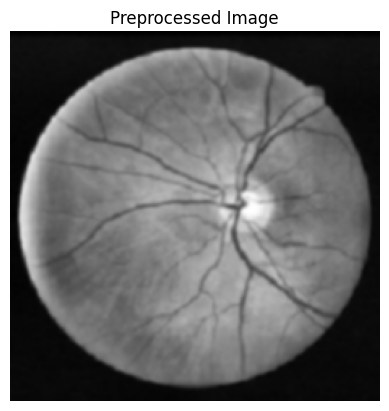

In [7]:
img = cv2.imread(image_paths[0])
mask = cv2.imread(mask_paths[0], 0)

gray = preprocess(img)
plt.imshow(gray, cmap='gray')
plt.title("Preprocessed Image")
plt.axis("off")

Niblack Analysis

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

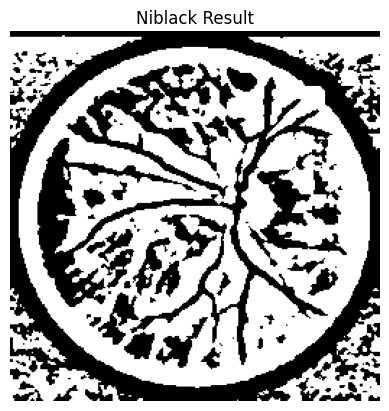

In [8]:
window = 25
th_niblack = threshold_niblack(gray, window_size=window, k=0.2)
binary_niblack = gray > th_niblack
binary_niblack = img_as_ubyte(binary_niblack)
plt.imshow(binary_niblack, cmap='gray')
plt.title("Niblack Result")
plt.axis("off")

Sauvola Analysis

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

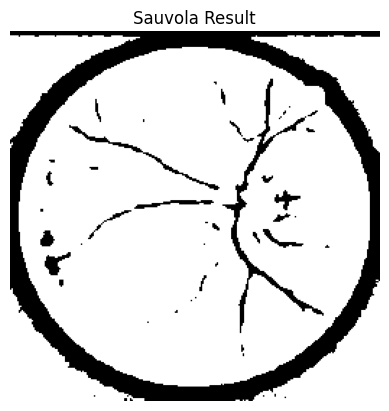

In [9]:
th_sauvola = threshold_sauvola(gray, window_size=window)
binary_sauvola = gray > th_sauvola
binary_sauvola = img_as_ubyte(binary_sauvola)
plt.imshow(binary_sauvola, cmap='gray')
plt.title("Sauvola Result")
plt.axis("off")

In [13]:
sens_nib, acc_nib = compute_metrics(binary_niblack, mask)
sens_sau, acc_sau = compute_metrics(binary_sauvola, mask)
print("Niblack Sensitivity = ", sens_nib)
print("Niblack Accuracy = ", acc_nib)
print("Sauvola Sensitivity = ", sens_sau)
print("Sauvola Accuracy = ", acc_sau)

Niblack Sensitivity =  0.6680024660905589
Niblack Accuracy =  0.46313476562492933
Sauvola Sensitivity =  0.9472872996291128
Sauvola Accuracy =  0.3190917968749513


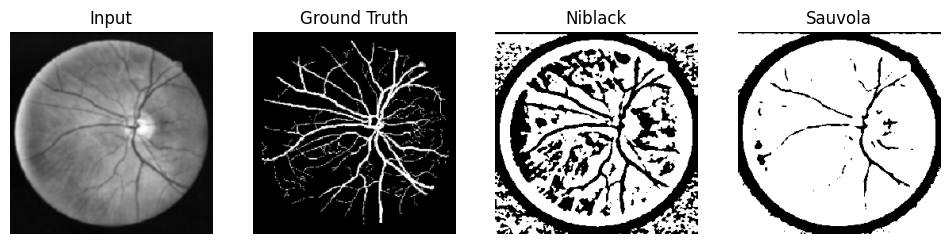

In [11]:
plt.figure(figsize=(12,6))
plt.subplot(1,4,1)
plt.imshow(gray, cmap='gray')
plt.title("Input")
plt.subplot(1,4,2)
plt.imshow(mask, cmap='gray')
plt.title("Ground Truth")
plt.subplot(1,4,3)
plt.imshow(binary_niblack, cmap='gray')
plt.title("Niblack")
plt.subplot(1,4,4)
plt.imshow(binary_sauvola, cmap='gray')
plt.title("Sauvola")

for i in range(4):
    plt.subplot(1,4,i+1).axis("off")

plt.show()

In [12]:
nib_scores = []
sau_scores = []

for i in range(5):
    img = cv2.imread(image_paths[i])
    mask = cv2.imread(mask_paths[i], 0)
    gray = preprocess(img)

    th_n = threshold_niblack(gray, 25, k=0.2)
    bin_n = img_as_ubyte(gray > th_n)

    th_s = threshold_sauvola(gray, 25)
    bin_s = img_as_ubyte(gray > th_s)

    nib_scores.append(compute_metrics(bin_n, mask)[0])
    sau_scores.append(compute_metrics(bin_s, mask)[0])

print("Avg Niblack Sensitivity = ", np.mean(nib_scores))
print("Avg Sauvola Sensitivity = ", np.mean(sau_scores))

Avg Niblack Sensitivity =  0.3870466030047949
Avg Sauvola Sensitivity =  0.9019912319600341
